In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.simulation import ChiralTwin


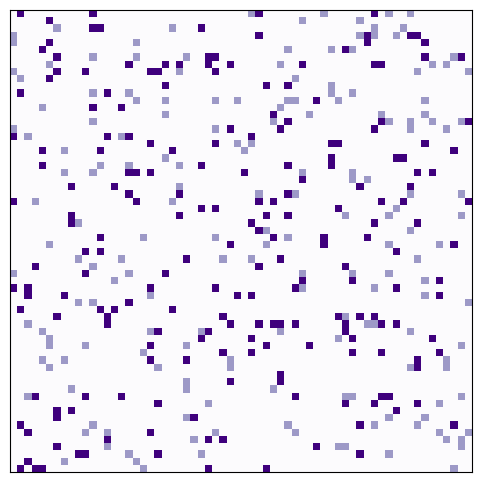

In [2]:
# Good initial condition
SIZE = (64, 64)
np.random.seed(42)
achiral_majority = np.random.choice([0, 1, 2], size=SIZE, p=[0.90, 0.05, 0.05])

plt.figure(figsize=(6, 6), dpi=100)
plt.imshow(achiral_majority, cmap='Purples', vmax=2)
plt.xticks([])
plt.yticks([])
plt.show()

# Save it
np.save('../data/initial-conditions/achiral_majority.npy', achiral_majority)

In [3]:
np.unique(achiral_majority, return_counts=True)

(array([0, 1, 2]), array([3703,  181,  212]))

In [4]:
config = {
    'simulation': {
        'total_steps': 100,
        'boundary_condition': 'periodic',
        'save_evolution': True,
        'save_images': True
    },
    'probs': {
        'dist_type': 'lognormal',
        'seed': 12,
        'p_neutral': 0.1,
        'p_chiral': 0.2,
        'p_copy': 0.5,
    },
    'chaos': {
        'mode': 'constant',

        'constant': {
            'epsilon': 1.0
        },

        'pulse': {
            'start_step': 30,
            'end_step': 60,
            'magnitude': 0.5
        },

        'linear_increase': {
            'start_epsilon': 0.0,
            'end_epsilon': 1.0
        }
    }
}

In [5]:
twin                = ChiralTwin(achiral_majority, config = config)
list0, list1, list2 = twin.timeEvolution()

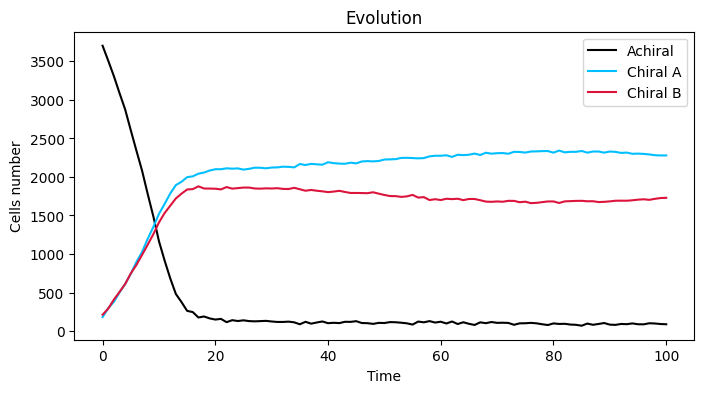

In [6]:
plt.figure(figsize=(8,4), dpi=100)
plt.plot(list0, label='Achiral', color='k')
plt.plot(list1, label='Chiral A', color='deepskyblue')
plt.plot(list2, label='Chiral B', color='crimson')
plt.xlabel('Time')
plt.ylabel('Cells number')
plt.title('Evolution')
# plt.ylim(0)
plt.legend()
plt.show()

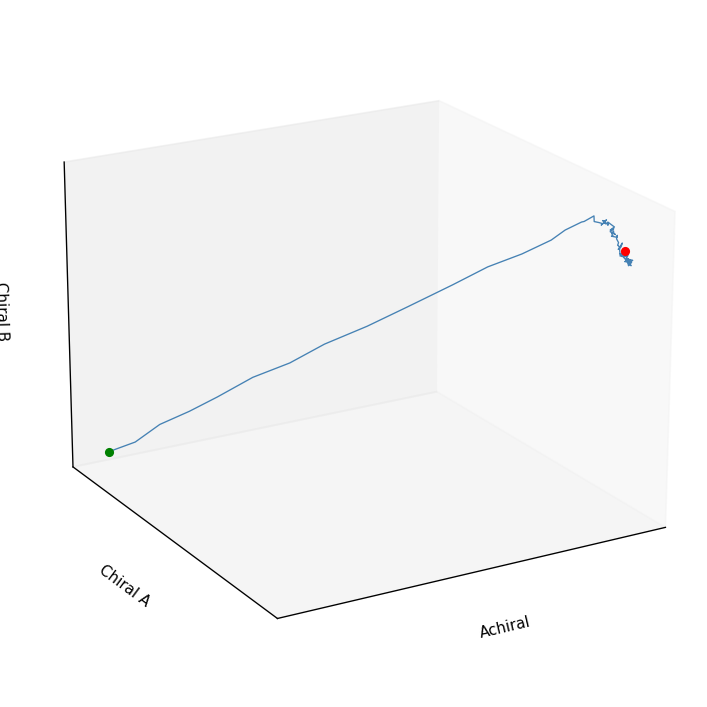

In [7]:
# Phase space (3D)
fig = plt.figure(figsize=(6, 6), dpi=120)
ax  = fig.add_subplot(111, projection='3d')

ax.plot(list0, list1, list2, lw=0.8, color='steelblue')
ax.scatter(list0[0],  list1[0],  list2[0],  color='green', s=20, zorder=5)  # start
ax.scatter(list0[-1], list1[-1], list2[-1], color='red',   s=20, zorder=5)  # end

ax.set_xlabel('Achiral',  fontsize=9)
ax.set_ylabel('Chiral A', fontsize=9)
ax.set_zlabel('Chiral B', fontsize=9)
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

# Angle
ax.view_init(elev=20, azim=60)

plt.tight_layout()
plt.show()


In [8]:
# Reading evolution and images box to plot
evol = pd.read_csv("data/time-evolution/constant-1.0_dist-lognormal/evolution.csv")
imag = np.load("data/time-evolution/constant-1.0_dist-lognormal/images.npy")

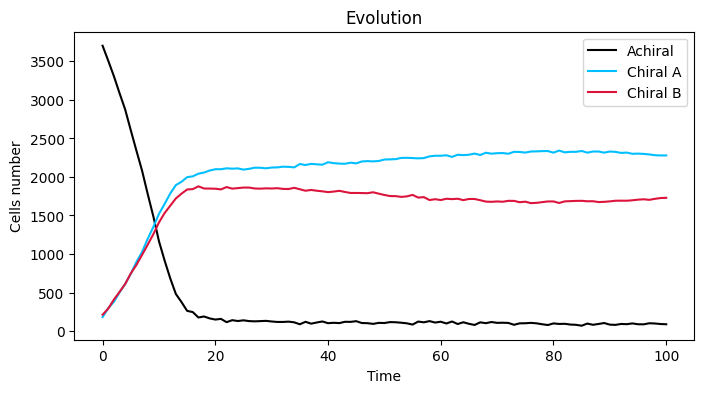

In [9]:
# ploting the evolution
plt.figure(figsize=(8,4), dpi=100)
plt.plot(evol['Achiral'], label='Achiral', color='k')
plt.plot(evol['Chiral A'], label='Chiral A', color='deepskyblue')
plt.plot(evol['Chiral B'], label='Chiral B', color='crimson')
plt.xlabel('Time')
plt.ylabel('Cells number')
plt.title('Evolution')
plt.legend()
plt.show()

In [10]:
np.unique(imag[0], return_counts=True)

(array([0, 1, 2]), array([3703,  181,  212]))

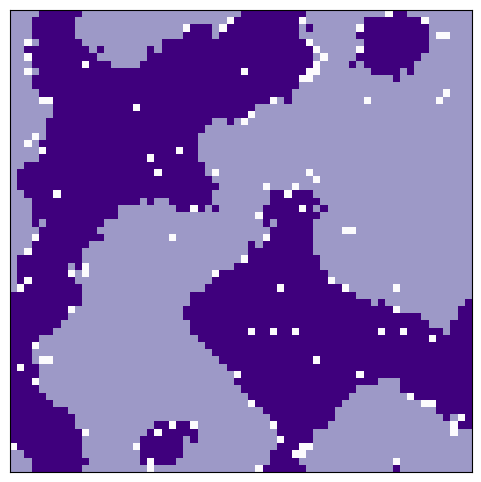

In [15]:
plt.figure(figsize=(6, 6), dpi=100)
plt.imshow(imag[50], cmap='Purples', vmax=2)
plt.xticks([])
plt.yticks([])
plt.show()

In [12]:
print(imag[0])

[[0 2 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 2 ... 0 0 0]
 [0 2 0 ... 1 0 0]]


In [ ]:
# Gif of images
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.animation import FuncAnimation, PillowWriter

# Expected shapes:
# (T, H, W) -> animation over time

# Class colors: 0,1,2
cmap = ListedColormap(["white", "#ea7ac6", "#658338"])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

fig, ax = plt.subplots()
im = ax.imshow(imag[0], cmap=cmap, norm=norm, interpolation="nearest")
ax.set_axis_off()

def update(t):
    im.set_data(imag[t])
    ax.set_title(f"t = {t}")
    return [im]

ani = FuncAnimation(fig, update, frames=imag.shape[0], interval=120, blit=True)

# Save GIF
ani.save("data/time-evolution/constant-1.0_dist-lognormal/images.gif", writer=PillowWriter(fps=8))
plt.close(fig)